In [1]:
# Imports
import os
import matplotlib.pyplot as plt
import essentia.standard as ess
import numpy as np
import glob
import mir_eval
import pandas as pd
from essentia.standard import *
from essentia import Pool, array
import librosa

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [2]:
# Function for onset detection - choose between one of three onset detection algorithms (HFC, Complex, Spectral flux)

def get_onsets(audio, fs, windowSize, hopSize, nFFT, method, alpha_value, delay_value):
    '''
    Given audio and short-time analysis parameters, find the onset detection function (ODF) 
    using chosen method, and post-process ODF to find peaks.
    
    'method' can be one of 'HFC', 'Flux', 'Complex'
    'alpha_value' is the 
    'delay_value' is the
    '''

    # to detect peaks in the output of the onset detection algorithm
    # see https://essentia.upf.edu/reference/std_Onsets.html
    onset_detector = Onsets(alpha = alpha_value, delay = delay_value, frameRate=fs/hopSize)

    w = Windowing(type = 'hann', zeroPadding=nFFT-windowSize)
    fft = FFT() # this gives us a complex FFT
    c2p = CartesianToPolar() # and this turns it into a pair (magnitude, phase)

    # Loading Essentia onset detection functions
    if method=='Complex':
        od_method = OnsetDetection(method='complex', sampleRate=fs)

    elif method=='Flux':
        od_method = Flux(halfRectify=True, norm='L1')

    elif method=='HFC':
        od_method = HFC(sampleRate=fs, type='Brossier')

    pool = Pool()
    for frame in FrameGenerator(audio, frameSize = windowSize, hopSize = hopSize):
        mag, phase, = c2p(fft(w(frame)))
        if method=='Complex':
            pool.add('features', od_method(mag, phase))
        else:
            pool.add('features', od_method(mag))

    onsets = onset_detector(array([pool['features']]),[1])

    return onsets

In [3]:
# File paths
audio_dir = '../audios/tabla_solo/PP/audios'
onset_gt_dir = '../audios/tabla_solo/PP/onsets'
audio_file_list = os.listdir(audio_dir)

In [4]:
# Short-time analysis parameters
fs = 16000
windowDur = 25e-3
hopDur = 5e-3
windowSize = int(np.ceil(windowDur*fs))
hopSize = int(np.ceil(hopDur*fs))
nFFT = 2**(int(np.ceil(np.log2(windowSize)))+1)

comp5_t.wav


[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...


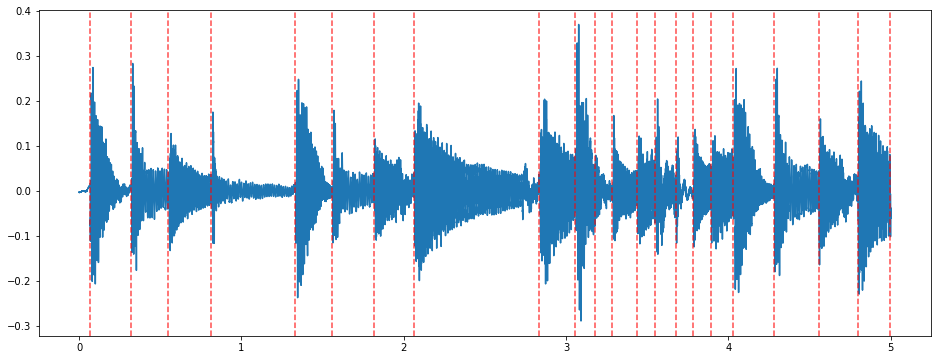

In [5]:
# Try on one audio file and plot results
method = 'HFC'#'HFC','Flux','Complex'

file_name = audio_file_list[0]
print(file_name)

#load audio
x,_ = librosa.load(os.path.join(audio_dir,file_name), sr = fs)

#select first 5 seconds for demonstration sake
x = x[:int(fs*5)]

#predict onsets
alpha = 0.1
delay = 2
onsets_pred = get_onsets(x, fs, windowSize, hopSize, nFFT, method, alpha, delay)

#plot audio and onsets
time = np.arange(len(x))*1/fs
plt.figure(figsize=(16,6))
plt.plot(time,x)
for onset in onsets_pred:
    plt.axvline(x=onset, linestyle='--', color='red', alpha=0.7)

Listen to the audio and verify if detected onsets seem correct. Are there too many false alarms? Re-run previous cell for different values of 'alpha' and 'delay'. What do you expect? What do you observe? Also try the other onset detection algorithms.

### Next, run on all audio files

For each audio, evaluate predicted onsets against ground truth to obtain precision, recall, f-score. Obtain the mean over all files. Sweep the value of alpha or delay to obtain a range of scores. Plot the precision-recall curve.

In [6]:
# Variables to store evaluation metrics
f_scores={}
precision={}
recall={}

tolerance = 50e-3 # if predicted onset within 50ms of ground truth onset, then it is marked a 'hit'
                  #; else, 'false-alarm'.

# Post-processing parameters
alpha_range = np.arange(0.1,0.5,0.05)
delay_value = 2

In [7]:
# Loop over alpha or delay values and all files (takes a minute...)

method = 'HFC'#'HFC','Flux','Complex'
f_scores[method] = np.zeros(len(alpha_range))
precision[method] = np.zeros(len(alpha_range))
recall[method] = np.zeros(len(alpha_range))

for i, alpha in enumerate(alpha_range):
    for file_name in audio_file_list:
        #load audio and ground truth onsets
        x,_ = librosa.load(os.path.join(audio_dir,file_name), sr = fs)
        onsets_gt = np.loadtxt(os.path.join(onset_gt_dir,file_name.replace('wav','txt')),usecols=(0))

        #predict onsets
        onsets_pred = get_onsets(x, fs, windowSize, hopSize, nFFT, method, alpha, int(delay_value))

        #evaluate predicted onsets against ground truth
        f_sc,pre,rec = mir_eval.onset.f_measure(onsets_gt, onsets_pred, tolerance)

        f_scores[method][i] += f_sc
        precision[method][i] += pre
        recall[method][i] += rec

f_scores[method] /= len(audio_file_list)
precision[method] /= len(audio_file_list)
recall[method] /= len(audio_file_list)

[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a 

[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a 

[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a 

[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 200 is not supported as frame rate.
This implementation depends on a 

Text(0.5, 1.0, 'Precision-recall curve')

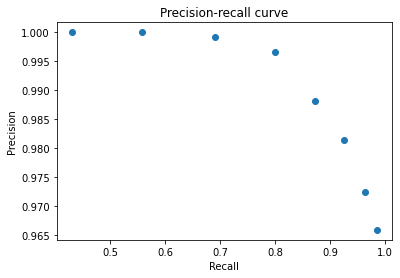

In [8]:
plt.scatter(recall[method][::-1],precision[method][::-1]) #the [::-1] indexing reverses the order of values
                                                          #how would plot look if indexing was not reversed?
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-recall curve')